# AirNow NO₂ — Extended Time Series Plots

Additional NO₂ visualisations built on the same AirNow dataset used in `01_explore_airnow.ipynb`.
All figures are saved to `../plots/`.

In [1]:
import sys, os
from pathlib import Path

_here = Path(os.getcwd()).resolve()
ROOT  = _here.parent if _here.name == 'notebooks' else _here
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

DATA_DIR  = '/mnt/data3/AirNow'
PLOTS_DIR = ROOT / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print(f"ROOT      : {ROOT}")
print(f"PLOTS_DIR : {PLOTS_DIR}")

ROOT      : /mnt/data3/isybelle1118/NO2 Forecasting
PLOTS_DIR : /mnt/data3/isybelle1118/NO2 Forecasting/plots


In [2]:
from data.load_airnow import load_all, site_meta

df   = load_all(DATA_DIR)
meta = site_meta(DATA_DIR)

coverage = df.notna().mean()
mean_no2 = df.mean()

print(f"Shape  : {df.shape}  ({df.shape[0]} hours × {df.shape[1]} sites)")
print(f"Range  : {df.index[0]}  →  {df.index[-1]}")

Shape  : (10992, 197)  (10992 hours × 197 sites)
Range  : 2023-07-01 00:00:00  →  2024-09-30 23:00:00


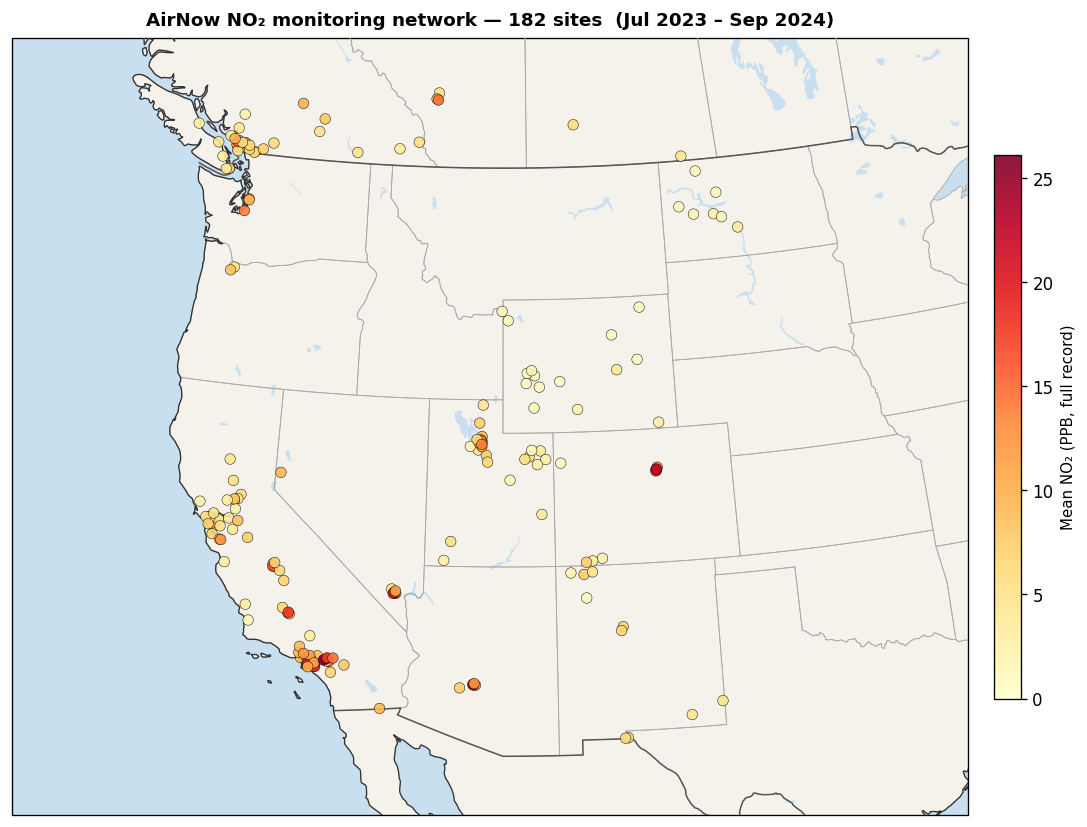

Saved site_map_cartopy.png  (182 sites plotted)


In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# All sites that appear in the loaded data
valid_sites = meta.index.intersection(df.columns)
meta_v = meta.loc[valid_sites]

proj     = ccrs.AlbersEqualArea(central_longitude=-111, central_latitude=40,
                                 standard_parallels=(29.5, 45.5))
data_crs = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(11, 7), subplot_kw={"projection": proj})
ax.set_extent([-128, -95, 29, 52], crs=data_crs)

# ── Map background ───────────────────────────────────────────────────────────
ax.add_feature(cfeature.OCEAN.with_scale("50m"),    facecolor="#c8dff0", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("50m"),     facecolor="#f5f1eb", zorder=1)
ax.add_feature(cfeature.LAKES.with_scale("50m"),    facecolor="#c8dff0", zorder=2)
ax.add_feature(cfeature.STATES.with_scale("50m"),   edgecolor="#aaaaaa", linewidth=0.5, zorder=3)
ax.add_feature(cfeature.BORDERS.with_scale("50m"),  edgecolor="#555555", linewidth=0.9, zorder=4)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="#333333", linewidth=0.8, zorder=5)

# ── Site dots ────────────────────────────────────────────────────────────────
sc = ax.scatter(
    meta_v["lon"].values,
    meta_v["lat"].values,
    c=mean_no2.reindex(valid_sites).values,
    cmap="YlOrRd",
    s=40,
    alpha=0.9,
    edgecolors="k",
    linewidths=0.3,
    transform=data_crs,
    zorder=6,
    vmin=0,
)
cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7, pad=0.02)
cbar.set_label("Mean NO₂ (PPB, full record)", fontsize=9)

ax.set_title(
    f"AirNow NO₂ monitoring network — {len(valid_sites)} sites  "
    f"(Jul 2023 – Sep 2024)",
    fontsize=11, fontweight="bold", pad=8,
)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "site_map_cartopy.png", dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved site_map_cartopy.png  ({len(valid_sites)} sites plotted)")


## 1. Top-N Highest-NO₂ Sites

Each legend entry shows **`Station Name  [AQS_code  lat°N, lon°W]`** so you can immediately identify and locate any site. The top sites are almost always near-road monitors (placed beside major freeways to measure traffic exhaust) or dense urban neighbourhoods — see the README for full descriptions of these sites.

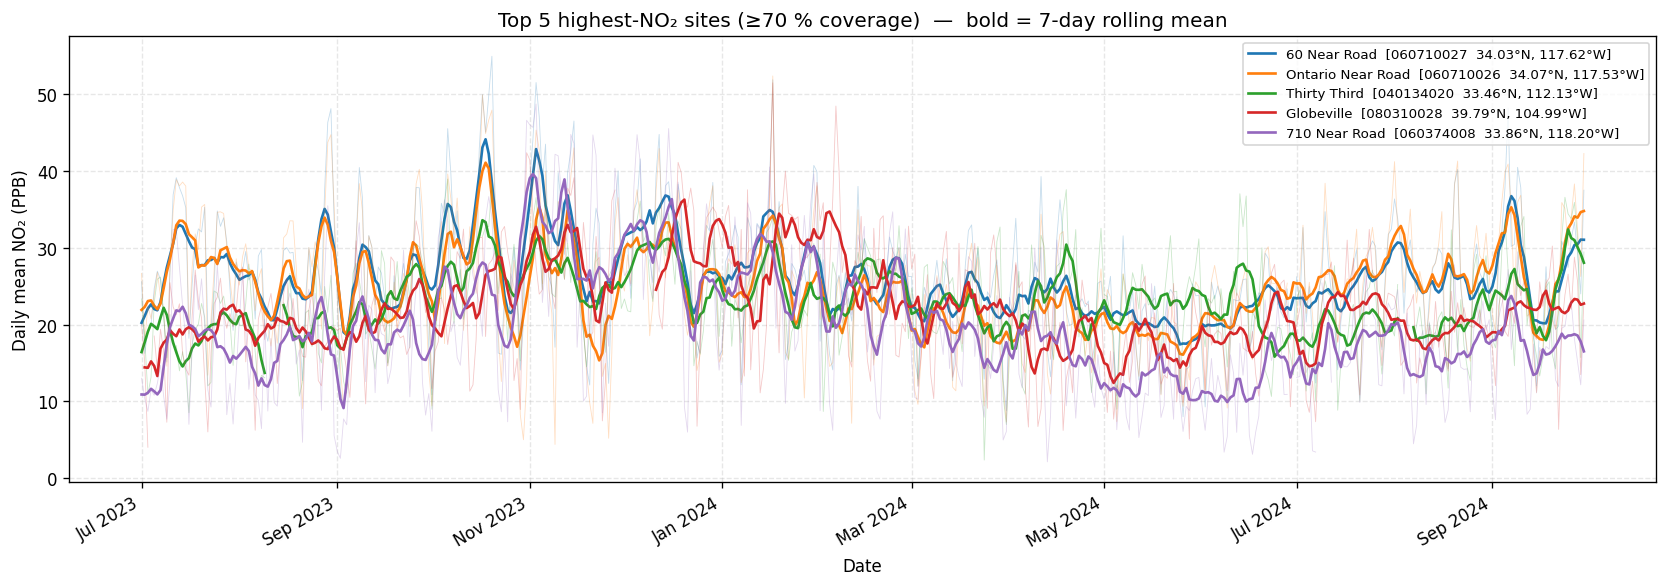

Saved ts_top_sites.png


In [3]:
# Top 5 sites by mean NO₂ (min 70 % coverage so we get full traces)
TOP_N    = 5
palette  = plt.cm.tab10.colors
eligible = coverage[coverage >= 0.70].index
top_sites = mean_no2[eligible].nlargest(TOP_N)

fig, ax = plt.subplots(figsize=(14, 5))
for i, (site, _) in enumerate(top_sites.items()):
    daily  = df[site].resample('D').mean()
    smooth = daily.rolling(7, center=True, min_periods=4).mean()
    name   = meta.loc[site, 'name'] if site in meta.index else site
    lat    = meta.loc[site, 'lat']  if site in meta.index else float('nan')
    lon    = meta.loc[site, 'lon']  if site in meta.index else float('nan')
    label  = f"{name}  [{site}  {lat:.2f}°N, {abs(lon):.2f}°W]"
    # light raw line for context, bold 7-day smoothed line as the main signal
    ax.plot(daily.index,  daily.values,  lw=0.5, color=palette[i], alpha=0.25)
    ax.plot(smooth.index, smooth.values, lw=1.6, color=palette[i], label=label)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Daily mean NO₂ (PPB)')
ax.set_title(f'Top {TOP_N} highest-NO₂ sites (≥70 % coverage)  —  bold = 7-day rolling mean')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ts_top_sites.png', dpi=150)
plt.show()
print('Saved ts_top_sites.png')


## 2. Regional groupings — West / Central / East

/tmp/ipykernel_1527696/1940734664.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


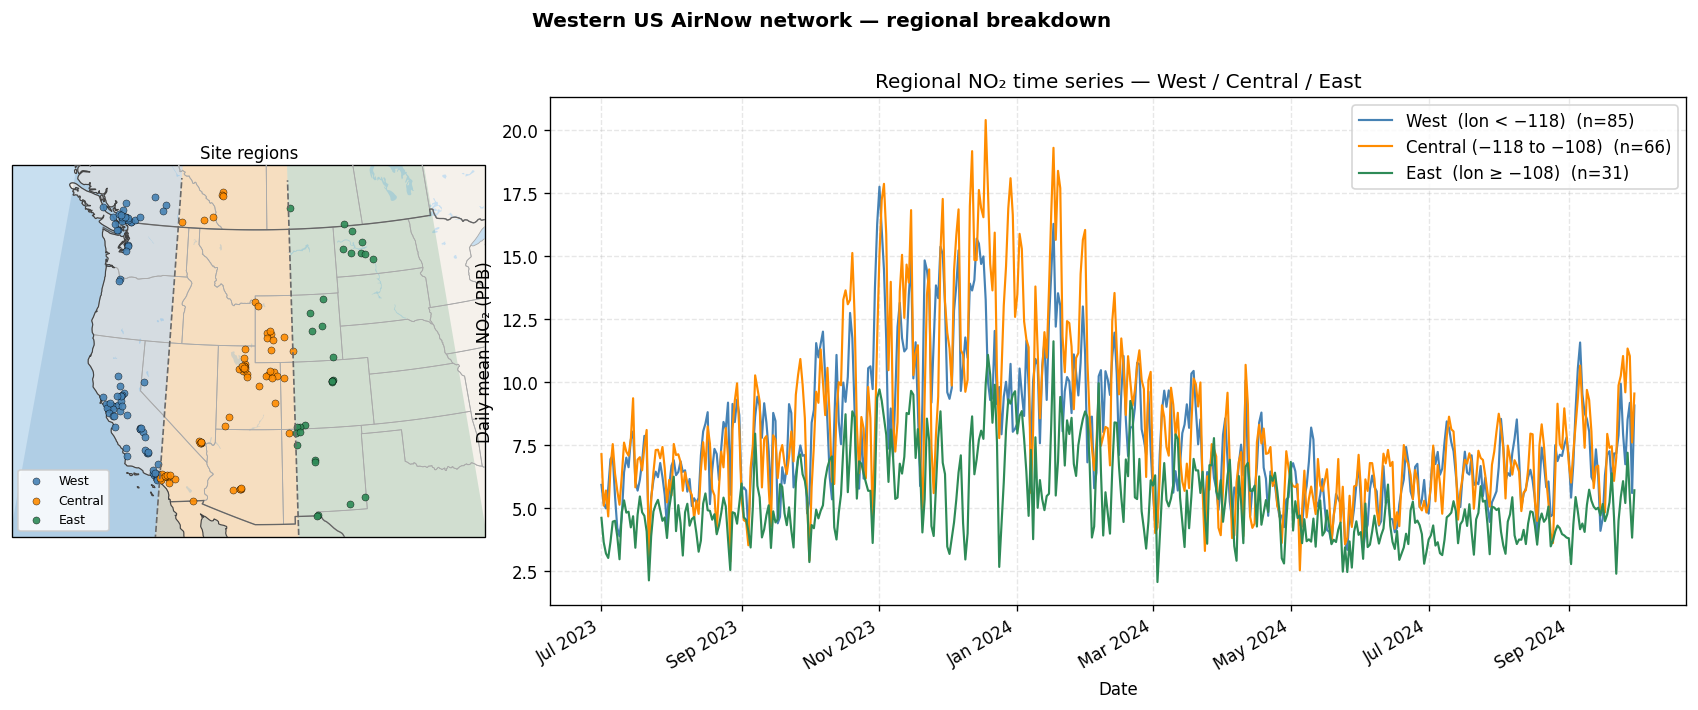

Saved ts_regional.png


In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec

common = meta.index.intersection(df.columns)
meta_c = meta.loc[common]

# West < −118 | Central −118 to −108 | East ≥ −108
regions = {
    'West  (lon < −118)':       meta_c[meta_c['lon'] < -118].index,
    'Central (−118 to −108)':   meta_c[(meta_c['lon'] >= -118) & (meta_c['lon'] < -108)].index,
    'East  (lon ≥ −108)':       meta_c[meta_c['lon'] >= -108].index,
}
region_colors = {
    'West  (lon < −118)':     'steelblue',
    'Central (−118 to −108)': 'darkorange',
    'East  (lon ≥ −108)':     'seagreen',
}
# Longitude extents for each shaded band
region_lon_bands = {
    'West  (lon < −118)':     (-128, -118),
    'Central (−118 to −108)': (-118, -108),
    'East  (lon ≥ −108)':     (-108,  -95),
}

proj     = ccrs.AlbersEqualArea(central_longitude=-111, central_latitude=40,
                                 standard_parallels=(29.5, 45.5))
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(18, 5.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 2.4], wspace=0.08)

# ── Left panel: map with colour-filled region bands + site dots ──────────────
ax_map = fig.add_subplot(gs[0], projection=proj)
ax_map.set_extent([-128, -95, 30, 52], crs=data_crs)

ax_map.add_feature(cfeature.OCEAN.with_scale('50m'),    facecolor='#c8dff0', zorder=0)
ax_map.add_feature(cfeature.LAND.with_scale('50m'),     facecolor='#f5f1eb', zorder=1)
ax_map.add_feature(cfeature.LAKES.with_scale('50m'),    facecolor='#c8dff0', zorder=2)
ax_map.add_feature(cfeature.STATES.with_scale('50m'),   edgecolor='#aaaaaa', linewidth=0.5, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale('50m'),  edgecolor='#666666', linewidth=0.8, zorder=4)
ax_map.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor='#444444', linewidth=0.7, zorder=5)

# Colour-filled longitude bands
for region, (lon_min, lon_max) in region_lon_bands.items():
    color = region_colors[region]
    xs = [lon_min, lon_max, lon_max, lon_min]
    ys = [24,      24,      56,      56     ]
    ax_map.fill(xs, ys, color=color, alpha=0.18,
                transform=data_crs, zorder=2, linewidth=0)

# Site dots coloured by region
for region, sites in regions.items():
    lats = meta_c.loc[sites, 'lat'].values
    lons = meta_c.loc[sites, 'lon'].values
    ax_map.scatter(lons, lats, color=region_colors[region], s=18, alpha=0.9,
                   edgecolors='k', linewidths=0.25,
                   transform=data_crs, zorder=6,
                   label=region.split('(')[0].strip())

# Dashed boundary lines between regions
for lon_bnd in (-118, -108):
    ax_map.plot([lon_bnd, lon_bnd], [28, 52], color='dimgrey',
                lw=1.0, ls='--', transform=data_crs, zorder=7)

ax_map.set_title('Site regions', fontsize=10, pad=4)
ax_map.legend(loc='lower left', fontsize=7.5, framealpha=0.85)

# ── Right panel: regional time series ────────────────────────────────────────
ax_ts = fig.add_subplot(gs[1])
for region, sites in regions.items():
    sites_in_df = [s for s in sites if s in df.columns]
    if not sites_in_df:
        print(f'WARNING: no sites found for {region}')
        continue
    daily_region = df[sites_in_df].mean(axis=1).resample('D').mean()
    daily_region = daily_region.interpolate(method='time', limit=3)
    ax_ts.plot(daily_region.index, daily_region.values,
               lw=1.3, color=region_colors[region],
               label=f'{region}  (n={len(sites_in_df)})')

ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_ts.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax_ts.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax_ts.set_xlabel('Date')
ax_ts.set_ylabel('Daily mean NO₂ (PPB)')
ax_ts.set_title('Regional NO₂ time series — West / Central / East')
ax_ts.legend()
ax_ts.grid(True, linestyle='--', alpha=0.3)

fig.suptitle('Western US AirNow network — regional breakdown', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ts_regional.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ts_regional.png')


## 3. Seasonal overlays — average NO₂ by month of year

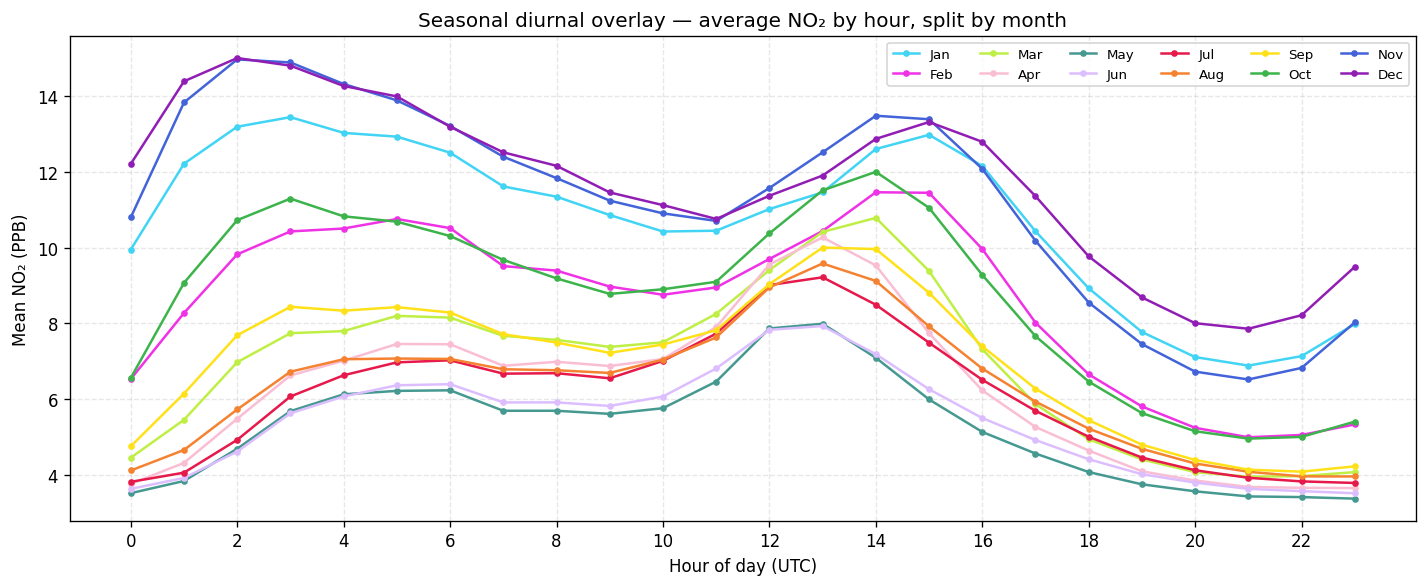

Saved ts_seasonal_overlay.png


In [5]:
# Average hourly NO₂ across all sites, grouped by month + hour → daily profile per month
network_hourly = df.mean(axis=1)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
season_colors = {
    'Jul': '#e6194b', 'Aug': '#f58231', 'Sep': '#ffe119',
    'Oct': '#3cb44b', 'Nov': '#4363d8', 'Dec': '#911eb4',
    'Jan': '#42d4f4', 'Feb': '#f032e6', 'Mar': '#bfef45',
    'Apr': '#fabed4', 'May': '#469990', 'Jun': '#dcbeff',
}

fig, ax = plt.subplots(figsize=(12, 5))
for m in range(1, 13):
    subset = network_hourly[network_hourly.index.month == m]
    diurnal = subset.groupby(subset.index.hour).mean()
    name    = month_names[m - 1]
    ax.plot(diurnal.index, diurnal.values, lw=1.5,
            color=season_colors[name], label=name, marker='o', markersize=3)

ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Mean NO₂ (PPB)')
ax.set_title('Seasonal diurnal overlay — average NO₂ by hour, split by month')
ax.set_xticks(range(0, 24, 2))
ax.legend(ncol=6, fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ts_seasonal_overlay.png', dpi=150)
plt.show()
print('Saved ts_seasonal_overlay.png')

## 4. Rolling average / smoothed trends

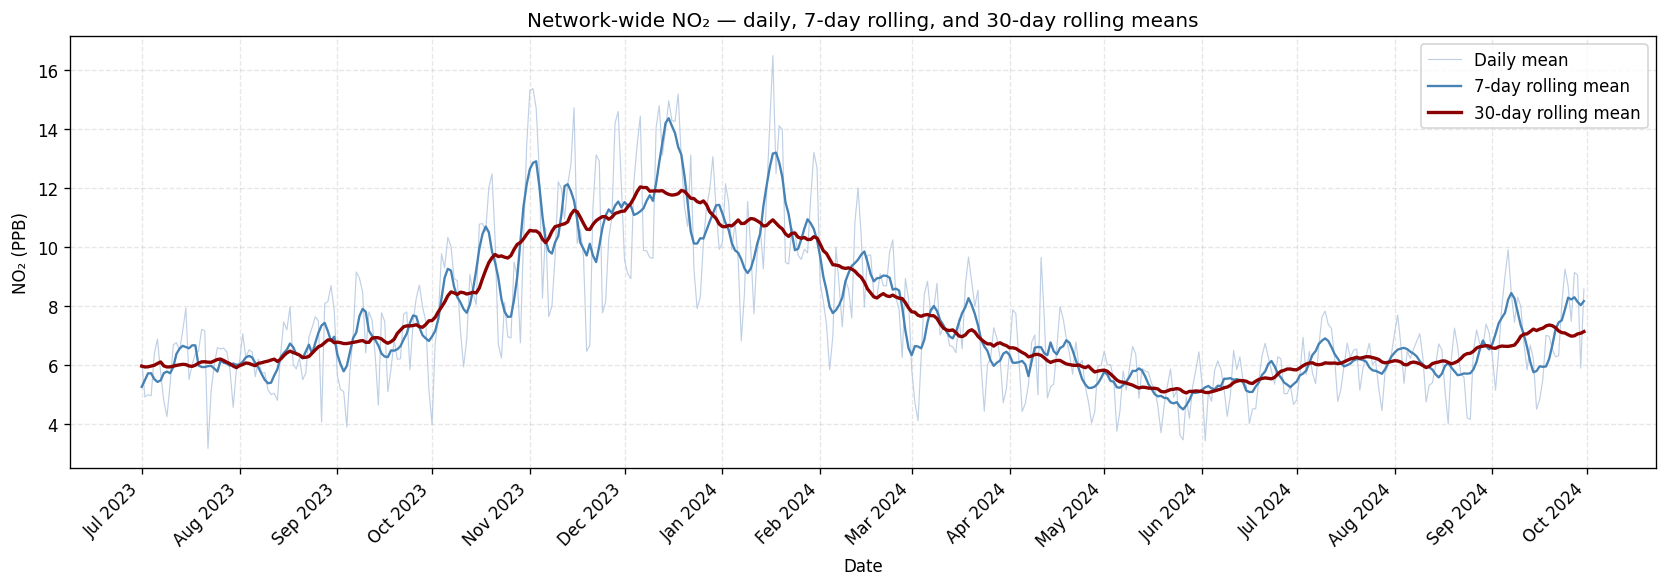

Saved ts_rolling_avg.png


In [6]:
daily_all = df.mean(axis=1).resample('D').mean()

roll7  = daily_all.rolling(7,  center=True, min_periods=4).mean()
roll30 = daily_all.rolling(30, center=True, min_periods=15).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_all.index, daily_all.values,
        color='lightsteelblue', lw=0.7, alpha=0.8, label='Daily mean')
ax.plot(roll7.index,  roll7.values,
        color='steelblue', lw=1.4, label='7-day rolling mean')
ax.plot(roll30.index, roll30.values,
        color='darkred',   lw=2.0, label='30-day rolling mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('NO₂ (PPB)')
ax.set_title('Network-wide NO₂ — daily, 7-day rolling, and 30-day rolling means')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ts_rolling_avg.png', dpi=150)
plt.show()
print('Saved ts_rolling_avg.png')

## 5. Anomaly plot — deviation from the long-term daily mean

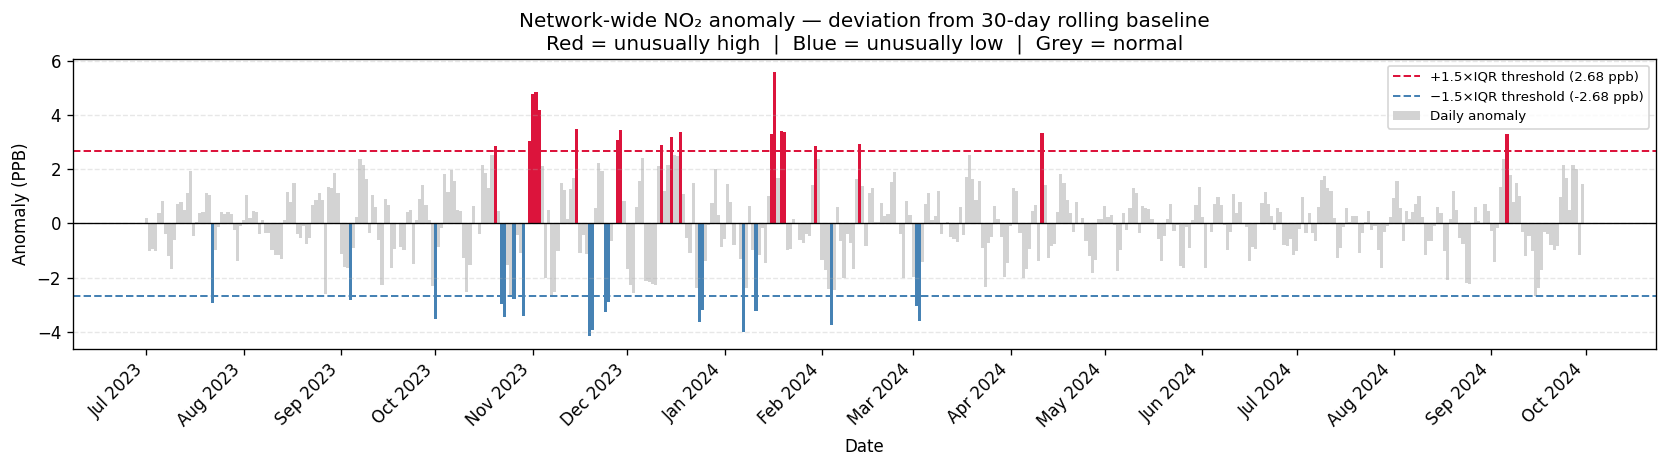

High-anomaly days : 19
Low-anomaly  days : 18
Saved ts_anomaly.png


In [7]:
# Anomaly = daily value minus the 30-day rolling baseline
baseline = daily_all.rolling(30, center=True, min_periods=15).mean()
anomaly  = daily_all - baseline

# Flag days more than 1.5× IQR above/below the anomaly distribution
q1, q3  = anomaly.quantile(0.25), anomaly.quantile(0.75)
iqr     = q3 - q1
pos_threshold =  1.5 * iqr
neg_threshold = -1.5 * iqr

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(anomaly.index, anomaly.values,
       color=np.where(anomaly > pos_threshold, 'crimson',
             np.where(anomaly < neg_threshold, 'steelblue', 'lightgrey')),
       width=1.0, label='Daily anomaly')
ax.axhline(pos_threshold, color='crimson',   lw=1.2, linestyle='--',
           label=f'+1.5×IQR threshold ({pos_threshold:.2f} ppb)')
ax.axhline(neg_threshold, color='steelblue', lw=1.2, linestyle='--',
           label=f'−1.5×IQR threshold ({neg_threshold:.2f} ppb)')
ax.axhline(0, color='black', lw=0.8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Anomaly (PPB)')
ax.set_title('Network-wide NO₂ anomaly — deviation from 30-day rolling baseline\n'
             'Red = unusually high  |  Blue = unusually low  |  Grey = normal')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ts_anomaly.png', dpi=150)
plt.show()

n_high = (anomaly > pos_threshold).sum()
n_low  = (anomaly < neg_threshold).sum()
print(f'High-anomaly days : {n_high}')
print(f'Low-anomaly  days : {n_low}')
print('Saved ts_anomaly.png')

## 6. Anomaly detection overlay — spikes highlighted on the time series

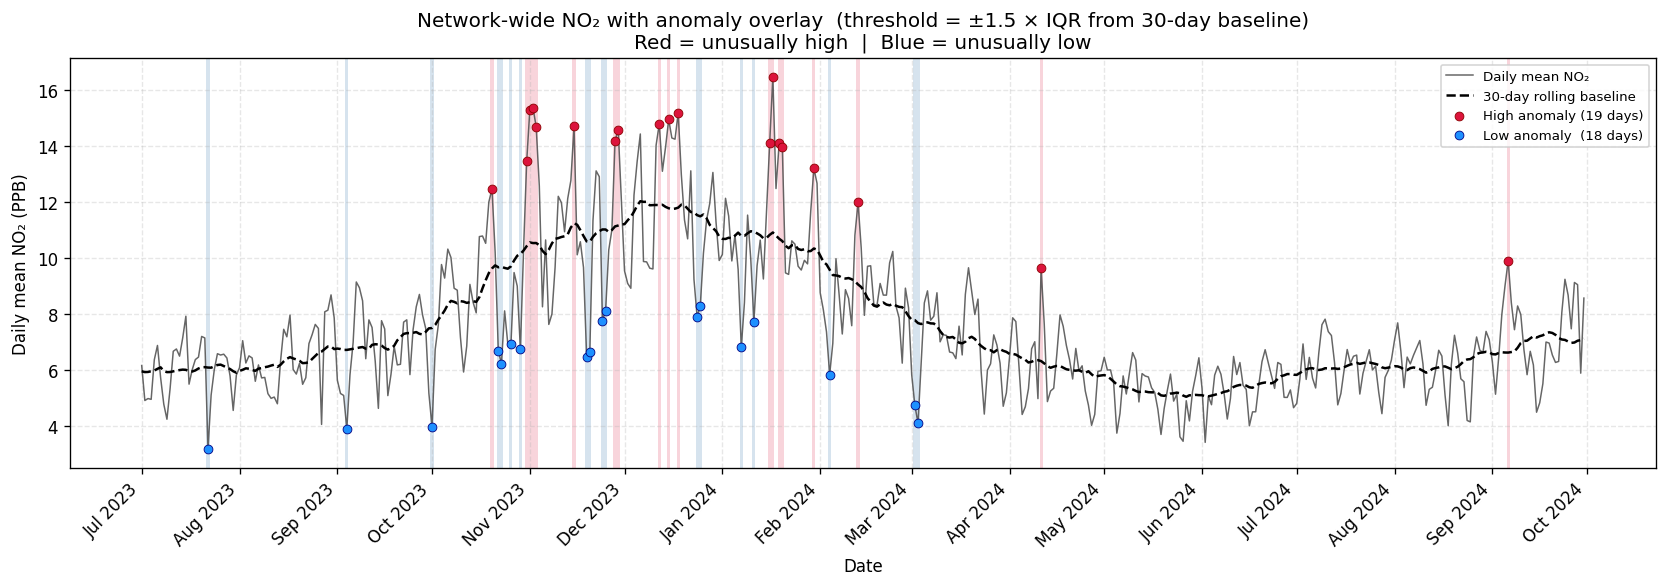

High anomaly days : 19
Low anomaly  days : 18
Saved ts_anomaly_overlay.png


In [8]:
daily_ts  = df.mean(axis=1).resample('D').mean()
baseline  = daily_ts.rolling(30, center=True, min_periods=15).mean()
anomaly   = daily_ts - baseline

q1, q3    = anomaly.quantile(0.25), anomaly.quantile(0.75)
threshold = 1.5 * (q3 - q1)

high_idx = anomaly.index[anomaly >  threshold]
low_idx  = anomaly.index[anomaly < -threshold]

fig, ax = plt.subplots(figsize=(14, 5))

# Shade each anomalous day
for d in high_idx:
    ax.axvspan(d - pd.Timedelta('12h'), d + pd.Timedelta('12h'),
               color='crimson', alpha=0.18, linewidth=0)
for d in low_idx:
    ax.axvspan(d - pd.Timedelta('12h'), d + pd.Timedelta('12h'),
               color='steelblue', alpha=0.22, linewidth=0)

# Raw daily series + rolling baseline
ax.plot(daily_ts.index, daily_ts.values,
        color='#555555', lw=0.9, alpha=0.9, label='Daily mean NO₂')
ax.plot(baseline.index, baseline.values,
        color='black', lw=1.5, ls='--', label='30-day rolling baseline')

# Event markers
ax.scatter(high_idx, daily_ts.loc[high_idx],
           color='crimson', s=28, zorder=6, edgecolors='darkred', linewidths=0.5,
           label=f'High anomaly ({len(high_idx)} days)')
ax.scatter(low_idx, daily_ts.loc[low_idx],
           color='dodgerblue', s=28, zorder=6, edgecolors='navy', linewidths=0.5,
           label=f'Low anomaly  ({len(low_idx)} days)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Daily mean NO₂ (PPB)')
ax.set_title(
    'Network-wide NO₂ with anomaly overlay  (threshold = ±1.5 × IQR from 30-day baseline)\n'
    'Red = unusually high  |  Blue = unusually low')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'ts_anomaly_overlay.png', dpi=150)
plt.show()
print(f'High anomaly days : {len(high_idx)}')
print(f'Low anomaly  days : {len(low_idx)}')
print('Saved ts_anomaly_overlay.png')
